In [1]:
# Import Libraries
from numba import njit,prange
import numpy as np
from astropy.table import Table
import h5py
import multiprocessing
import os
import glob
from astropy.io import fits
from scipy.interpolate import interp1d
import catalogue_analysis as ca
from kcorrections  import DESI_KCorrection
import ColourModel as cm
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM,z_at_value
cosmo = FlatLambdaCDM(H0=100, Om0=0.313, Tcmb0=2.725)   #Standard Planck Cosmology in Mpc/h units
import time
import sys
import gc
import fitsio
from desimodel.footprint import is_point_in_desi

In [2]:
# Configure
reg='N'                    #North or South. rancat needs to have been produced for the same region. Consistency is checked
Sel=ca.selection(reg)      #Defines magnitude limits etc for this region

obs_seed= 234
sig_lgv = 0.02
min_Vpeak=70.0       #Discard all halos with Vpeak<min_Vpeak. This limits the redshift below which the mock is complete  
N_neigh_vpeak = 1000 #with 1000 the logVpeak scatter among neighbours is < 10^-6 and so will introduce no more than 10^-5 scatter in the magnitude relation


rancat=rf'./sdata/Mocks/input_rancat_{reg}0.fits'   #random catalogue to which the matching is made. It was made by RandomCatalogue.ipynb 
subhalo_fits=rf'./sdata/Mocks/subhalos_{reg}_{min_Vpeak:.1f}.fits'     #file to store a fits version of the selected part of uuchu. If already exists set readfulluuchu=False
mockcat=rf'./sdata/Mocks/mock_{reg}_seed{obs_seed:3d}_sig_lgv{sig_lgv:.2f}.fits'#file to store resulting mock catalogue
randoms_out=rf'./sdata/Mocks/randoms_{reg}.fits' #output random catalogue matching the sky footprint of the output mock



print('Output Checkpoint file:', subhalo_fits)
print('Output Mock catalogue file:', mockcat)
print('Input random catalogue file:', rancat)
print('Output random catalogue file:', randoms_out)


readfulluuchu = True  # If checkpoint file exists and you are not changing obs_seed, sig_lgv, N_neigh_peak or min_Vpeak then this can be set to False and it will run faster and on a login node
lbox=2000.0           #Box size of Uuchu simulation [0,lbox]
frac_box=0.8     # We cut a sphere of rsphere= frac_box*lbox from 2x2x2 replicas of the simulation cube
rsphere=lbox*frac_box # radius of comoving sphere we cut from the simulation and within which we create the mock  
RAmin = 120          #Region of sky within which we limit the mock.  These cuts are applied before saving subhalo_fits so should not be changed if reusing that dataset.
RAmax = 300
DECmin = 0
DECmax = 90
nzbins=100         #number of redshift windows
N_neigh=50      #Number of neighbours used to define secondary rank used in colour matching
usemask= True   #use official DR2 mask from the following file
tiles_file = '/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/tiles-BRIGHT.fits'
verbose_stats = False # If true the stats of the subhalo astro-py table are output after every stage
rancat_out = False  #don't bother outputting a random catalogue  (one version can suffice fro all random seeds and many parameter changes)

Output Checkpoint file: ./sdata/Mocks/subhalos_N_70.0.fits
Output Mock catalogue file: ./sdata/Mocks/mock_N_seed234_sig_lgv0.02.fits
Input random catalogue file: ./sdata/Mocks/input_rancat_N0.fits
Output random catalogue file: ./sdata/Mocks/randoms_N.fits


In [3]:
# Add gaussian scatter to log10(Vpeak) before ranking if required 
# Elena's preferred method involves two passes. 
# First with no scatter
# Second using absolute magnitude from the first pass with scatter added to replace the Vpeak using in the first match
def apply_log_scatter(x, sigma):
    """
    Apply log-normal scatter.

    Parameters
    ----------
    x : array-like
        Quantity to scatter (e.g. Vpeak).
    sigma : float
        Scatter in dex.

    Returns
    -------
    array-like
        Scattered version of x.
    """
    if sigma is None or sigma == 0.0:
        return x

    scatter = np.random.normal(loc=0.0, scale=sigma, size=len(x))
    return x * 10.0**scatter


In [4]:
#Read the previously saved fits file of the selected sample rather than rereading all of Uuchu
if not readfulluuchu:
    start_time = time.time()
    subhalos=Table.read(subhalo_fits)
    end_time = time.time()
    print(f"time to read saved pre-sorted Uuchu subhalos from fits file: {end_time - start_time:.1f} seconds")
    assert RAmax <= subhalos.meta['RAMAX'], f"RAmax limits not compatible: {RAmax} > {subhalos.meta['RAMAX']}"
    assert RAmin >= subhalos.meta['RAMIN'], f"RAmin limits not compatible: {RAmin} < {subhalos.meta['RAMIN']}"
    assert DECmax <= subhalos.meta['DECMAX'], f"DECmax limits not compatible: {DECmax} > {subhalos.meta['DECMAX']}"
    assert DECmin >= subhalos.meta['DECMIN'], f"DECmmin limits not compatible: {DECmin} < {subhalos.meta['DECMIN']}"
    assert RAmax <= subhalos.meta['RAMAX'], f"RAmax limits not compatible: {RAmax} > {subhalos.meta['RAMAX']}"
    assert min_Vpeak >= subhalos.meta['min_Vpeak'], f"min_Vpeak limits not compatible: {min_Vpeak} < {subhalos.meta['min_Vpeak']}"
    

In [5]:
#Generate a random set of Euler angles
def random_euler_angles(seed=None):

    rng = np.random.default_rng(seed)

    phi = 2.0 * np.pi * rng.random()

    costheta = 2.0 * rng.random() - 1.0
    theta = np.arccos(costheta)

    psi = 2.0 * np.pi * rng.random()

    return phi, theta, psi

#Compute the rotation matrix descrbed by a set of Euler angles
def euler_rotation_matrix(phi, theta, psi):

    c1 = np.cos(phi)
    s1 = np.sin(phi)

    c2 = np.cos(theta)
    s2 = np.sin(theta)

    c3 = np.cos(psi)
    s3 = np.sin(psi)

    Rz1 = np.array([
        [ c1, -s1, 0],
        [ s1,  c1, 0],
        [  0,   0, 1]
    ])

    Ry = np.array([
        [ c2, 0, s2],
        [  0, 1,  0],
        [-s2, 0, c2]
    ])

    Rz2 = np.array([
        [ c3, -s3, 0],
        [ s3,  c3, 0],
        [  0,   0, 1]
    ])

    return Rz1 @ Ry @ Rz2

In [6]:
# Uuchu routine adapted from those provided by Elena Fernandez

#   Reads one of the Uchu files and makes appends 7 periodic replicas
#   lbox is the simulation box size. coordinates assumed to be [0,lbox] 
#   frac_box < 1 cuts out a sphere of radius frac_box*lbox around the observer
#
def read_halolist_file_reps(file_path, randseed, columns, min_logMvir=10.4, min_Vpeak=0.0, lbox=2000.0, frac_box=0.8, xobs=0.0, yobs=0.0, zobs=0.0):

    shortname = os.path.basename(file_path)
    results = dict()

    #List of columns that we can recast as 32bit rather than native 64bit and hence save memory   
    float32_cols = {'vx', 'vy', 'vz','Mpeak_Scale','Rvir','rs','Vpeak'}

    with h5py.File(file_path, 'r') as f:
        for col in columns:
            arr = f[col][:]

            if col in float32_cols:
                arr = arr.astype(np.float32)

            results[col] = arr



    # --- Vpeak cut ---
    keep = (results['Vpeak'] >  min_Vpeak)
    nkeep = np.sum(keep)
    pkeep = 100 * nkeep / len(keep)
    print(f'{shortname} Global Vpeak cut: keeping {nkeep}/{len(keep)} ({pkeep:.1f}%) entries')

    for col in results:
        results[col] = results[col][keep]
        

    # --- mass cut ---
    keep = (results['Mvir_all'] > 10**min_logMvir)
    nkeep = np.sum(keep)
    pkeep = 100 * nkeep / len(keep)
    print(f'{shortname} Mvir_all cut: keeping {nkeep}/{len(keep)} ({pkeep:.1f}%) entries')

    for col in results:
        results[col] = results[col][keep]

    
    # ------------------------------------------------------------
    # Reposition the box about the chosen observer
    # ------------------------------------------------------------


    results['x'] = (results['x'] - xobs) % lbox
    results['y'] = (results['y'] - yobs) % lbox
    results['z'] = (results['z'] - zobs) % lbox

 # ------------------------------------------------------------------
    # Periodic replication with immediate radial cut.
    #
    # Instead of constructing the full 8-replica catalogue and then
    # throwing most of it away, process each replica separately and
    # retain only objects inside the target sphere.
    # ------------------------------------------------------------------

    shifts = np.array(
        np.meshgrid(
            [0, -lbox],
            [0, -lbox],
            [0, -lbox]
        )
    ).T.reshape(-1, 3)

    nrep = len(shifts)  # should be 8

    r2_max = (frac_box * lbox)**2

    out = {k: [] for k in results}

    for irep, (dx, dy, dz) in enumerate(shifts):

        # Shift coordinates for this replica only
        xrep = results['x'] + dx
        yrep = results['y'] + dy
        zrep = results['z'] + dz

        # Radial cut for this replica
        r2 = xrep*xrep + yrep*yrep + zrep*zrep
        keep = (r2 < r2_max)
            
        
        # Store coordinate columns
        out['x'].append(xrep[keep])
        out['y'].append(yrep[keep])
        out['z'].append(zrep[keep])

        # Store all remaining columns
        for k in results:

            if k in ('x', 'y', 'z'):
                continue

            elif k == 'id':
                # Make IDs unique across replicas
                out[k].append((results[k] * nrep + irep)[keep])

            else:
                out[k].append(results[k][keep])

    # Concatenate surviving halos from all replicas
    for k in out:
        out[k] = np.concatenate(out[k])


    return out






# Correspondence between snapshot and redshift
redshift_table = {
    33: 1.03, 
    34: 0.94,
    35: 0.86,
    36: 0.78,
    37: 0.70,
    38: 0.63,
    39: 0.56,
    40: 0.49,
    41: 0.43,
    43: 0.30,
    45: 0.19,
    47: 0.09,
    50: 0.00
}

# Onion shell boundaries used previously by Elena

#zmin zmax snapshot
#0.0 0.05 50
#0.05 0.10 47
#0.10 0.25 45
#0.25 0.40 43
#0.40 0.45 41
#0.45 0.50 40



In [7]:
def read_halolist_parallel(file_paths, randseed, columns, min_logMvir=10.4, min_Vpeak=0.0, lbox=2000.0, frac_box=0.8, xobs=0.0, yobs=0.0, zobs=0.0):

    nfiles = len(file_paths)

    args = []
    for i, filename in enumerate(file_paths):
        args.append([filename,randseed*nfiles+i,columns,min_logMvir,min_Vpeak,lbox,frac_box,xobs,yobs,zobs])
        

    ncpus= multiprocessing.cpu_count()
    nworkers = min(nfiles,ncpus)
    print("ncpus=",ncpus,"nworkers",nworkers)
    with multiprocessing.Pool(nworkers) as pool:
        file_results = pool.starmap(read_halolist_file_reps, args)
        
    tot_bytes = 0

    for d in file_results:
        for v in d.values():
            tot_bytes += v.nbytes

    print(f"All file_results = {tot_bytes/1024**3:.1f} GB")


    # concatenate across files without doubling memory usage
    results = {}
    cols = list(file_results[0].keys())
    for col in cols:

        results[col] = np.concatenate([x[col] for x in file_results])

        # immediately release this column from file_results
        for x in file_results:
            del x[col]
    #free up memory        
    del file_results
    gc.collect()

    return Table(results)

In [8]:

if readfulluuchu:
    start_time = time.time()
    # Read a sample of the Uuchu subhalos
    index=45 # select redshift snapshot
    redshift = redshift_table[index]

    #Choose random position for observer with seed offset from that used for observer direction
    offset=58
    rng = np.random.default_rng((obs_seed+offset))
    xobs = lbox * rng.random()
    yobs = lbox * rng.random()
    zobs = lbox * rng.random()
    print('Observer position:',xobs,yobs,zobs)
    
    # Define the directory containing the halo files
    print("Reading Uuchu data for redshift:",redshift)
    halodir = f"/global/cfs/cdirs/desi/mocks/cai/Uchuu-SHAM/Uchuu-halo-catalogs/halodir_{index:03d}"
    # List all the halo file
    halolist_files = sorted(glob.glob(f'{halodir}/halolist_*.h5'))

    print("number of files to read:",len(halolist_files))

    subhalos = read_halolist_parallel(halolist_files, randseed=0,  columns=('id', 'Mvir_all', 'Vpeak', 'x','y','z','vx','vy','vz','Mpeak_Scale', 'Rvir','rs'), 
                                      min_logMvir=9.0, min_Vpeak=min_Vpeak, lbox=lbox, frac_box=frac_box, xobs=xobs, yobs=yobs, zobs=zobs)
    end_time = time.time()
    print(f"time to read Uuchu from disk: {end_time - start_time:.1f} seconds")
    if verbose_stats: subhalos.info('stats')


Observer position: 1463.8450373865703 1419.9789357613936 1462.1120322228494
Reading Uuchu data for redshift: 0.19
number of files to read: 100
ncpus= 256 nworkers 100
halolist_z0p19_68.h5 Global Vpeak cut: keeping 9782045/42201702 (23.2%) entries
halolist_z0p19_68.h5 Mvir_all cut: keeping 9778574/9782045 (100.0%) entries
halolist_z0p19_86.h5 Global Vpeak cut: keeping 9780153/42226881 (23.2%) entries
halolist_z0p19_86.h5 Mvir_all cut: keeping 9776865/9780153 (100.0%) entries
halolist_z0p19_21.h5 Global Vpeak cut: keeping 9666892/41841648 (23.1%) entries
halolist_z0p19_21.h5 Mvir_all cut: keeping 9663751/9666892 (100.0%) entries
halolist_z0p19_60.h5 Global Vpeak cut: keeping 9780134/42239765 (23.2%) entries
halolist_z0p19_76.h5 Global Vpeak cut: keeping 9706954/41970245 (23.1%) entries
halolist_z0p19_60.h5 Mvir_all cut: keeping 9776976/9780134 (100.0%) entries
halolist_z0p19_76.h5 Mvir_all cut: keeping 9703735/9706954 (100.0%) entries
halolist_z0p19_93.h5 Global Vpeak cut: keeping 974235

In [9]:
if readfulluuchu:
    print("A quick look at the data types of the subhalos table before we add RA, DEC and redshift:")
    for k in subhalos.colnames:
        print(k, subhalos[k].dtype)
        
    start_time = time.time()

    #Generate random Euler angle and corresponding rotation matrix
    phi, theta, psi = random_euler_angles(seed=obs_seed)
    print("Euler angles:",phi,theta,psi)
    R = euler_rotation_matrix(phi, theta, psi)
    #Rotate the velocities
    vxr = R[0,0]*subhalos['vx'] + R[0,1]*subhalos['vy'] + R[0,2]*subhalos['vz']
    vyr = R[1,0]*subhalos['vx'] + R[1,1]*subhalos['vy'] + R[1,2]*subhalos['vz']
    vzr = R[2,0]*subhalos['vx'] + R[2,1]*subhalos['vy'] + R[2,2]*subhalos['vz']
    #Overwrite originals and delete temporary arrays    
    subhalos['vx'] = vxr
    subhalos['vy'] = vyr
    subhalos['vz'] = vzr
    del vxr,vyr,vzr
    
                                  
    #Rotate positions 
    xr = R[0,0]*subhalos['x'] + R[0,1]*subhalos['y'] + R[0,2]*subhalos['z']
    yr = R[1,0]*subhalos['x'] + R[1,1]*subhalos['y'] + R[1,2]*subhalos['z']
    zr = R[2,0]*subhalos['x'] + R[2,1]*subhalos['y'] + R[2,2]*subhalos['z']
    #Overwrite originals and delete temporary arrays    
    subhalos['x'] = xr
    subhalos['y'] = yr
    subhalos['z'] = zr
    del xr,yr,zr

    
    end_time = time.time()
    print(f"time to rotate coordinates: {end_time - start_time:.1f} seconds")

    start_time = time.time()
        
    # Compute RA DEC and redshift
    subhalos['dist']= np.sqrt( (subhalos['x'])**2 + (subhalos['y'])**2 + (subhalos['z'])**2 ) #distance from observer at origin of original box
    subhalos['DEC']= np.degrees(np.arcsin((subhalos['z'])/subhalos['dist']))
    subhalos['RA'] = np.degrees(np.arctan2((subhalos['y']), (subhalos['x']))) % 360


    # compute radial velocity over speed of light
    c=299792.458  # speed of light in km/s
    vr_c=( subhalos['x']*subhalos['vx'] + subhalos['y']*subhalos['vy'] + subhalos['z']*subhalos['vz'] ) / (c*subhalos['dist'])

    #Free up space by deleting velocities
    subhalos.remove_column('vx')
    subhalos.remove_column('vy')
    subhalos.remove_column('vz')
    gc.collect() #garbage collection

    #Compute concentration
    subhalos['conc']=subhalos['Rvir']/subhalos['rs']

    #Free up space
    subhalos.remove_column('Rvir')
    subhalos.remove_column('rs')
    gc.collect() #garbage collection

    
    #First build lookup table between comoving distance and redshift
    z_grid = np.linspace(0.0, 1.0, 10000)
    Dc_grid = ca.cosmo.comoving_distance(z_grid).value  # Mpc/h

    z_of_Dc = interp1d(
        Dc_grid,
        z_grid,
        bounds_error=False,
        fill_value="extrapolate"
    )
    subhalos['Zu'] = z_of_Dc(subhalos['dist'])

    subhalos['Zobs'] = (1.0+subhalos['Zu'])*(1.0+vr_c) -1.0
    subhalos.rename_column('id', 'ID')
    del z_grid,Dc_grid,z_of_Dc,vr_c
    end_time = time.time()
    print(f"time to compute RA, DEC and redshift: {end_time - start_time:.1f} seconds")
    
if verbose_stats: subhalos.info("stats")

A quick look at the data types of the subhalos table before we add RA, DEC and redshift:
id int64
Mvir_all float64
Vpeak float32
x float64
y float64
z float64
vx float32
vy float32
vz float32
Mpeak_Scale float32
Rvir float32
rs float32
Euler angles: 5.0291893595019435 1.6692837356025534 1.771094589426556
time to rotate coordinates: 69.7 seconds
time to compute RA, DEC and redshift: 263.8 seconds


In [10]:
# Make all columns in a astro-py table contiguous in memory 
# which might help numba code to be more efficent
def make_all_columns_contiguous(tab):
    for name in tab.colnames:
        col = tab[name]
        # Convert column to contiguous array **without changing dtype**
        arr_contig = np.ascontiguousarray(col)
        tab[name] = arr_contig
    return tab



In [11]:
# compute the rms scatter in quantity z among the N_neigh neighbours of each element in the array
@njit(parallel=True)
def compute_scatter(z, N_neigh):
    zloc=z #make a temporary local copy which might help cache usage and numba efficency
    n = len(z)
    sigma = np.zeros(n, dtype=np.float32)
    half = N_neigh // 2

    for i in prange(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        total=hi-lo-1  #total in range minus self-count

        zi = zloc[i]
        sumsq = 0

        for j in range(lo, hi):
            sumsq=sumsq+(zloc[j]-zi)**2


        if total > 0:
            sigma[i] = sumsq / total
        else:
            sigma[i] = np.nan

    return sigma

In [12]:
@njit(parallel=True)
def compute_frac_local_mpeak(mpeak_scale, N_neigh):

    n = len(mpeak_scale)
    frac = np.zeros(n, dtype=np.float32)
    half = N_neigh // 2

    for i in prange(n):

        lo = max(0, i - half)
        hi = min(n, i + half + 1)

        total = hi - lo - 1

        ai = mpeak_scale[i]

        count = 0

        for j in range(lo, hi):

            # Equivalent to zpeak[j] > zpeak[i]
            if mpeak_scale[j] < ai:
                count += 1

        if total > 0:
            frac[i] = count / total
        else:
            frac[i] = np.nan

    return frac


@njit(parallel=True)
def compute_frac_local(z, N_neigh):
    zloc=z #make a temporary local copy which might help cache usage and numba efficency
    n = len(z)
    frac = np.zeros(n, dtype=np.float32)
    half = N_neigh // 2

    for i in prange(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        total=hi-lo-1  #total in range minus self-count

        zi = zloc[i]
        count = 0

        for j in range(lo, hi):
            if zloc[j] > zi:
                count += 1

        if total > 0:
            frac[i] = count / total
        else:
            frac[i] = np.nan

    return frac


@njit(parallel=True)
def match_2d_many_to_one(sub_frac, rand_frac, target_rank, W, lam):

    n_sub = len(sub_frac)
    n_rand = len(rand_frac)
    invW=1.0/W

    match_idx = np.empty(n_sub, dtype=np.int64)

    for i in prange(n_sub):

        j0 = target_rank[i]

        # clamp to valid range
        if j0 < 0:
            j0 = 0
        elif j0 >= n_rand:
            j0 = n_rand - 1

        lo = max(0, j0 - W)
        hi = min(n_rand, j0 + W + 1)

        best_j = j0
        best_cost = 1e30

        fi = sub_frac[i]

        for j in range(lo, hi):
            rank_term = abs(j - j0)*invW
            frac_term = abs(fi - rand_frac[j])

            cost = lam * rank_term + (1.0 - lam) * frac_term

            if cost < best_cost:
                best_cost = cost
                best_j = j

        match_idx[i] = best_j

    return match_idx

In [13]:
# i) Sort the subhalos into decreasing order of Vpeak 
# ii) Compute fraction of neighbours with higher zpeak
#iii) Add acstter to Vpeak and sort again
# iv) Trim the catalogue by applying a tailored Vpeak(z) threshold
def pre_sort_subhalos(subhalos,N_neigh=100,sig_lgv=0.0):
    
    start_time = time.time()
    print("Starting sort")
    subhalos.sort('Vpeak')
    print("Sort complete")
    subhalos.reverse()
    print("Reversal complete")
    end_time = time.time()
    print(f"time to sort subhalos: {end_time - start_time:.4f} seconds")

    nsub = len(subhalos)


  
    # ------------------------------------------------------------------
    # compute FRAC (local rank statistic)
    # ------------------------------------------------------------------
    start_time = time.time()
    #Remove quantization of Mpeak_Scale by adding noise in memory efficient method
    mps = subhalos['Mpeak_Scale'] #creates a pointer to this array
    rng = np.random.default_rng()
    nr=len(subhalos['Mpeak_Scale'])
    noise = rng.random(len(mps), dtype=np.float32)
    noise -= 0.5  #centre noise at zero
    noise *= 0.01 #scale amplitude of noise
    mps += noise  #add noise
    del noise  #delete temporary array
    subhalos['FracZpeak'] = compute_frac_local_mpeak(subhalos['Mpeak_Scale'],N_neigh=N_neigh)
    end_time = time.time()
    print(f"time to compute FracZpeak: {end_time - start_time:.4f} seconds")


    if (sig_lgv>0.0):
        #Add scatter to Vpeak
        start_time = time.time()
        subhalos['Vpeak']=apply_log_scatter(subhalos['Vpeak'], sig_lgv)
        end_time = time.time()
        print(f"time to add Vpeak scatter: {end_time - start_time:.4f} seconds")

        start_time = time.time()
        print("Starting 2nd sort")
        subhalos.sort('Vpeak')
        print("Sort complete")
        subhalos.reverse()
        print("Reversal complete")
        end_time = time.time()
        print(f"time to sort subhalos: {end_time - start_time:.4f} seconds")

    # Rank index
    start_time = time.time()
    subhalos['i1'] = np.arange(1, nsub + 1, dtype=np.int32)
    end_time = time.time()
    print(f"time to define rank index: {end_time - start_time:.4f} seconds")
    
    # ------------------------------------------------------------------
    # Distance dependent trimming
    # ------------------------------------------------------------------
    start_time = time.time()
    dist=subhalos['dist']
    limit = ((6.5e-07 * dist - 9.02e-04) * dist + 0.486) * dist + 10.0
    mask = subhalos['Vpeak'] >limit
    subhalos['keep'] = mask
    end_time = time.time()
    print(f"time to define distance dependent trimming mask: {end_time - start_time:.4f} seconds")

    return subhalos

In [14]:
# Memory efficient way of shrinking a table keeping only the values with 
# column'keep' True
def filter_table_staged(tab, mask, drop_mask=True, mask_name='keep'):

    new_cols = {}
    
    # Process columns one by one
    for col in list(tab.colnames):
        if col == mask_name:
            continue
        
        # Create filtered column
        new_cols[col] = tab[col][mask]
        
        # Immediately delete original column to free memory
        tab.remove_column(col)

    # Optionally drop mask column
    if drop_mask and mask_name in tab.colnames:
        tab.remove_column(mask_name)

    # Now rebuild table from filtered columns
    new_tab = Table(new_cols)

    return new_tab


    

In [15]:
# Sort the subhalo table in decreasing order of Vpeak.
# Define the secondary macthing variable FracZpeak with respect to neighbours in Vpeak.
# Add scatter to Vpeak and resort
# set up column 'i1' giving the rank in this ordered table and
# define a column 'keep' if above a distance dependent Vpeak cut    
if readfulluuchu:
    start_time = time.time()
    subhalos= make_all_columns_contiguous(subhalos)
    end_time = time.time()
    print(f"time to make subhalos contiguous: {end_time - start_time:.1f} seconds")
    subhalos=pre_sort_subhalos(subhalos,N_neigh=N_neigh_vpeak,sig_lgv=sig_lgv)  
    if verbose_stats: subhalos.info('stats')

time to make subhalos contiguous: 21.9 seconds
Starting sort
Sort complete
Reversal complete
time to sort subhalos: 395.9390 seconds


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


time to compute FracZpeak: 25.0822 seconds
time to add Vpeak scatter: 75.1478 seconds
Starting 2nd sort
Sort complete
Reversal complete
time to sort subhalos: 480.2812 seconds
time to define rank index: 2.1213 seconds
time to define distance dependent trimming mask: 13.2177 seconds


In [16]:
if readfulluuchu:
    start_time = time.time()
    # Reduce the size of the subhalo table by removing the objects with subhalos['keep']=False. Also deletes the 'keep' column
    subhalos = filter_table_staged(subhalos, subhalos['keep'], drop_mask=True, mask_name='keep')
    gc.collect() #garbage collection
    end_time = time.time()
    print(f"time to apply vpeak(distance) cut: {end_time - start_time:.1f} seconds")
    if verbose_stats: subhalos.info('stats')

time to apply vpeak(distance) cut: 36.0 seconds


In [17]:
# Cut to an RA DEC patch or to a mask made to match the DESI data to have a small sample for tests
if usemask:
    tiles = fitsio.read(tiles_file) #read the official tiles/mask file
    if (reg=='N'):
        mask = is_point_in_desi(tiles, subhalos['RA'], subhalos['DEC']) # in whole of official DESI DR2 mask
        mask = mask & (subhalos['RA']>85.0) & (subhalos['RA']<305.0) &  (subhalos['DEC']>32.375) #cut to portion in region North
    else:    
        mask = (subhalos['RA']>85.0) & (subhalos['RA']<305.0) &  (subhalos['DEC']>32.375) # region that includes DESI North and none of DESI South
        mask = ~mask & is_point_in_desi(tiles, subhalos['RA'], subhalos['DEC']) # in whole of official DESI DR2 mask but with ~mask excludes the North
    subhalos= subhalos[mask]
    del mask,tiles

    
else:
    start_time = time.time()
    subhalos["keep"]= (subhalos["RA"]>RAmin)  & (subhalos["RA"]<RAmax) & (subhalos["DEC"]>DECmin)  & (subhalos["DEC"]<DECmax) 
    subhalos = filter_table_staged(subhalos, subhalos['keep'], drop_mask=True, mask_name='keep')
    end_time = time.time()
    print(f"time to apply RA DEC selection: {end_time - start_time:.1f} seconds")


if verbose_stats: subhalos.info("stats")

Uuchu number and box size: 8377253 2000.0


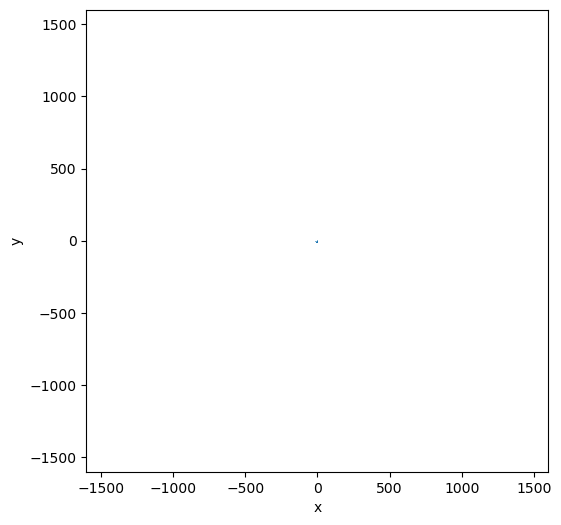

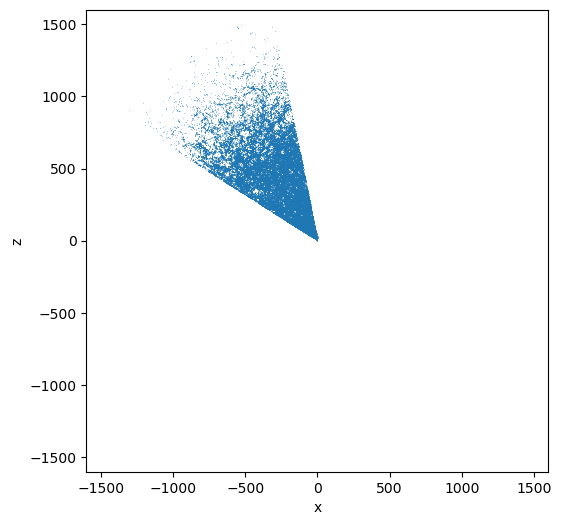

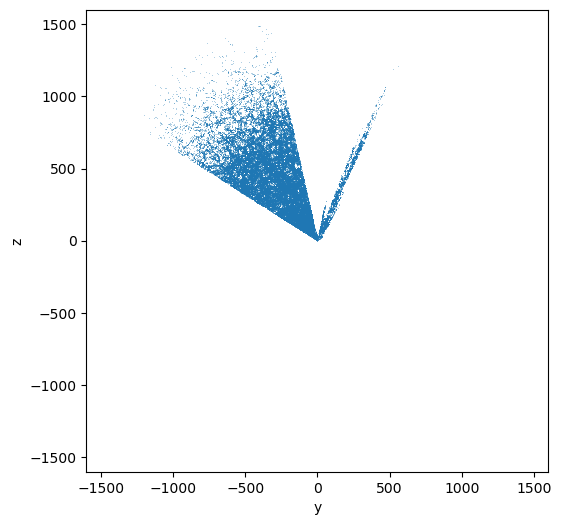

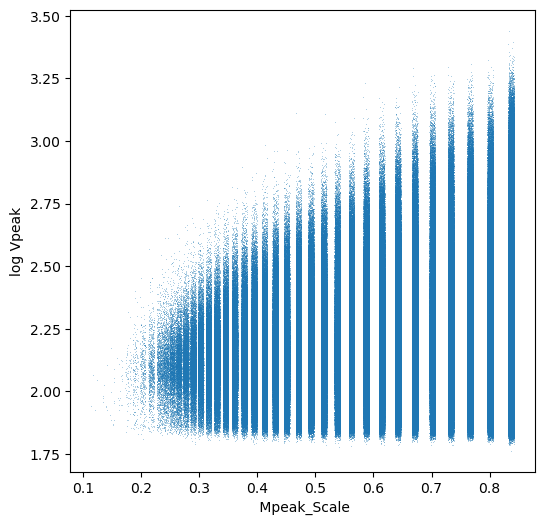

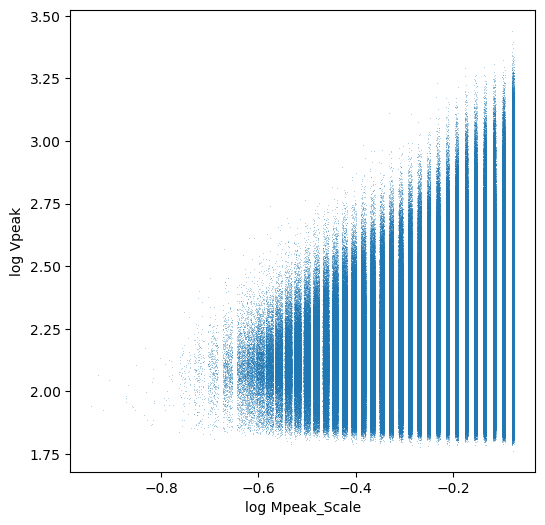

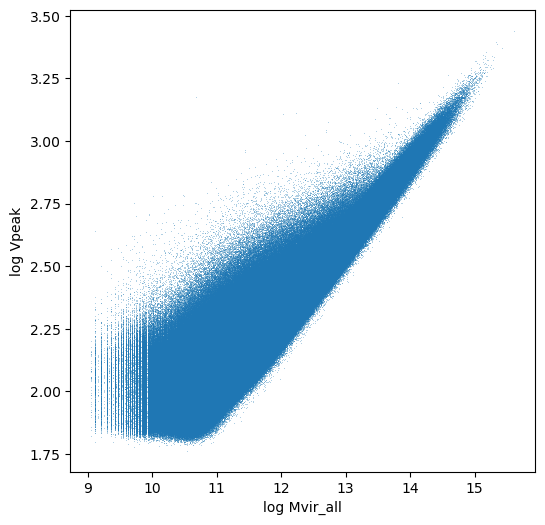

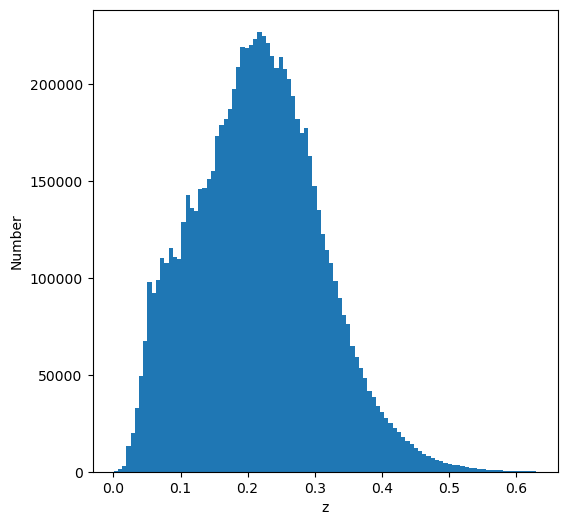

In [18]:
# Inspect uuchu dataset and define the redshift,RA, DEC and other parameters that we may use in matching



nbox=len(subhalos)
print('Uuchu number and box size:',nbox,lbox)



fig, ax = plt.subplots(figsize=(6, 6))
mask = (np.absolute(subhalos['z'])<10.0)
ax.scatter(subhalos['x'][mask],subhalos['y'][mask],marker='.',lw=0,s=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-1600,1600)
ax.set_ylim(-1600,1600)
ax.set_aspect("equal")
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
mask = (np.absolute(subhalos['y'])<10.0)
ax.scatter(subhalos['x'][mask],subhalos['z'][mask],marker='.',lw=0,s=0.5)
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_xlim(-1600,1600)
ax.set_ylim(-1600,1600)
ax.set_aspect("equal")
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
mask = (np.absolute(subhalos['x'])<10.0)
ax.scatter(subhalos['y'][mask],subhalos['z'][mask],marker='.',lw=0,s=0.5)
ax.set_xlabel('y')
ax.set_ylabel('z')
ax.set_xlim(-1600,1600)
ax.set_ylim(-1600,1600)
ax.set_aspect("equal")
fig.show()



# Inspect other properties such as the distribution of Vpeak and Mpeak_scale

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(subhalos['Mpeak_Scale'],np.log10(subhalos['Vpeak']),marker='.',lw=0,s=0.5)
ax.set_xlabel(' Mpeak_Scale')
ax.set_ylabel('log Vpeak')
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.log10(subhalos['Mpeak_Scale']),np.log10(subhalos['Vpeak']),marker='.',lw=0,s=0.5)
ax.set_xlabel('log Mpeak_Scale')
ax.set_ylabel('log Vpeak')
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.log10(subhalos['Mvir_all']),np.log10(subhalos['Vpeak']),marker='.',lw=0,s=0.5)
ax.set_xlabel('log Mvir_all')
ax.set_ylabel('log Vpeak')
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(subhalos['Zu'],bins=100)
ax.set_xlabel('z')
ax.set_ylabel('Number')
fig.show()





In [19]:
#Write selected catalogue to disk for future use
if readfulluuchu:
    start_time = time.time()
    subhalos.meta["RAmin"]=RAmin  #store meta data with subhaloes so consistency can be checked.
    subhalos.meta["RAmax"]=RAmax
    subhalos.meta["DECmin"]=DECmin
    subhalos.meta["DECmax"]=DECmax 
    subhalos.meta["min_Vpeak"]=min_Vpeak 
    subhalos.write("sdata/subhalos70S.fits",overwrite=True)
    end_time = time.time()
    print(f"time to write checkpoint Uchuu catalogue: {end_time - start_time:.1f} seconds")



time to write checkpoint Uchuu catalogue: 4.5 seconds


In [20]:
#Load the random catalogue into a astro-py table
start_time = time.time()
randoms=Table.read(rancat)
print('Meta data',randoms.meta)
if (reg=='S') :
    nmult=randoms.meta['NMULTS'] # This is the factor by which the density is higher in this random catalogue than the corresponding data
elif  (reg=='N') :
    nmult=randoms.meta['NMULTN'] # This is the factor by which the density is higher in this random catalogue than the corresponding data   
print('nmult=',nmult)
DeltaZ=randoms.meta["DELTAZ"]
print("DeltaZ=",DeltaZ)
regran=randoms.meta["REG"]
print("Random Catalogue was generated with the selection function of region ",regran)
assert regran == reg, f"Faint limits do not match: {regran} != {reg}"
#add and index/id
randoms['ID'] = np.arange(len(randoms), dtype=np.int64)
end_time = time.time()
print(f"time to read Randoms: {end_time - start_time:.1f} seconds")
if verbose_stats: randoms.info('stats')



Meta data {'EXTNAME': 'LSS', 'NMULTN': 12.085460012396961, 'DELTAZ': 0.03, 'REG': 'N'}
nmult= 12.085460012396961
DeltaZ= 0.03
Random Catalogue was generated with the selection function of region  N
time to read Randoms: 4.7 seconds


In [21]:
def abundance_match_subhalos_to_randoms(
    subhalos,
    ran,
    lbox,
    rsphere,
    fsky,
    z_bins,
    scatter_sigma=None,
    DeltaZ=0.03,
):
    """
    NumPy-based abundance matching with minimal memory overhead.
    """
    kcorr_r  = DESI_KCorrection(band='R', file='jmext', photsys=reg) 
    # ------------------------------------------------------------
    # Extract NumPy arrays (no copies yet)
    # ------------------------------------------------------------
    sub_id = subhalos['ID']
    sub_vpeak = subhalos['Vpeak']
    sub_z = subhalos['Zu']
    i1= subhalos['i1']

    ran_id = ran['ID']
    ran_mag=ran['ABSMAG_R']
    ran_gp = ran['ABSMAG_GP1']
    ran_rp = ran['ABSMAG_RP1']
    ran_rmag = ran['rmag']
    ran_z = ran['Z']
    ran_zmin = ran['zmin']
    ran_zmax = ran['zmax']


    # ------------------------------------------------------------
    # Sort randoms once by luminosity (brightest first)
    # ------------------------------------------------------------
    ran_order = np.argsort(ran_mag)  # more negative mag = brighter
    ran_id = ran_id[ran_order]
    ran_z = ran_z[ran_order]
    ran_zmin = ran_zmin[ran_order]
    ran_zmax = ran_zmax[ran_order]
    ran_gp = ran_gp[ran_order]
    ran_rp = ran_rp[ran_order]
    ran_mag =ran_mag[ran_order]
    

    # ------------------------------------------------------------
    # Output containers (column-wise, memory-efficient)
    # ------------------------------------------------------------
    out_sub = []
    out_gal = []

    V_sim = (4.0*np.pi/3.0)* (rsphere**3)  #Volume cut from simulatin box within which ranking was performed. Needed for scaling.

    # ------------------------------------------------------------
    # Loop over redshift slices
    # ------------------------------------------------------------
    for zmin, zmax in zip(z_bins[:-1], z_bins[1:]):

        zmin_ex=np.maximum(0.0,zmax-DeltaZ)
        # Boolean masks (cheap views)
        sub_m = (sub_z >= zmin) & (sub_z < zmax)
        ran_m = (ran_z >= zmin_ex) & (ran_z < zmax) & (ran_zmax>=zmax)
        
       
        if not sub_m.any() or not ran_m.any(): #If nothing in one or other slice move to next slice
            continue

        # Indices
        sub_idx = np.nonzero(sub_m)[0] #returns as a numpy array the indices of the subhaloes in the redshift slice i.e. for which the mask is True
        ran_idx = np.nonzero(ran_m)[0] #returns as a numpy array the indices of the random galaxies in the redshift slice i.e. for which the mask is True

        
        V_slice = fsky * (4.0*np.pi/3.0)*( (ca.cosmo.comoving_distance(zmax).value)**3 -(ca.cosmo.comoving_distance(zmin_ex).value)**3  ) #volume of shell in random catalogue
        R = V_sim / V_slice # volume ratio needed for scaling when making matches

        print("Processing slice:",zmin,"<z<",zmax,"Nsubs=",sub_m.sum(),"Nrans=",ran_m.sum(),' R=',R)

        # ------------------------------------------------------------
        # Pure luminosity SHAM mapping
        # ------------------------------------------------------------
        target_rank = np.rint(i1[sub_idx] / R).astype(np.int64) - 1

        valid = (target_rank >= 0) & (target_rank < len(ran_idx))

        if not np.any(valid):
            continue

        sub_idx_valid = sub_idx[valid]
        match_local = target_rank[valid]



#  code to do secondary matching

        rng = np.random.default_rng()
        f_test = rng.random(len(sub_idx_valid))
        
        colour = (ran_gp - ran_rp).astype(np.float32)
        fracz = subhalos['FracZpeak'][sub_idx_valid]


        matched_gal_ids = np.empty(len(sub_idx_valid), dtype=ran_id.dtype)

        if (N_neigh != 0): # Do secondary matching over N_neigh neighbours

            half = N_neigh // 2

            for i, (j0, f) in enumerate(zip(match_local, fracz)):

                lo = max(0, j0 - half)
                hi = min(len(ran_idx), j0 + half + 1)

                # candidate galaxies in this luminosity neighbourhood
                neigh = np.arange(lo, hi)

                # sort by colour (bluest -> reddest)
                colour_order = np.argsort(colour[ran_idx[neigh]])

                nloc = len(colour_order)

                # percentile position
                k = min(nloc - 1,max(0,int(np.floor((1-f) * (nloc - 1)))))  

        

                chosen = neigh[colour_order[k]]

                matched_gal_ids[i] = ran_id[ran_idx[chosen]]

        else: #only do the primary matching
                matched_gal_ids = ran_id[ran_idx[match_local]]  
                
              
        # ------------------------------------------------------------
        # Store results
        # ------------------------------------------------------------
        out_sub.extend(sub_id[sub_idx_valid])
        out_gal.extend(matched_gal_ids)

       


    # ------------------------------------------------------------
    # When all slices are processed return the complete matched list
    # as two corresponding numpy arrays
    # ------------------------------------------------------------
    return np.asarray(out_sub), np.asarray(out_gal)

In [22]:


# Abundance match
kcorr_r  = ca.DESI_KCorrection(band='R', file='jmext', photsys=reg) 
Sel=ca.selection(reg)
print('nmult=',nmult)
fsky=Sel['area']*nmult #fraction of sky covered by the random catalogue including the factor by which it oversamples


z_bins = np.linspace(Sel['zmin'], Sel['zmax'], nzbins)

start_time = time.time()

# Returns the id of each subhalo and the id of the galaxy it is matched with
subhalo_id,galaxy_id = abundance_match_subhalos_to_randoms(
    subhalos=subhalos,
    ran=randoms,
    lbox=lbox,        # simulation box size [Mpc/h]
    rsphere=rsphere,  # radius of sphere cut from the simulation
    fsky=fsky,        # effective fraction of sky covered by the random galaxy catalogue  
    z_bins=z_bins,    # redshift bin edges
    scatter_sigma=0.0, # dex scatter to add to Vpeak
    DeltaZ=DeltaZ,    #redshift limiter that was used when making the random catalogue
)

end_time = time.time()
print(f"Elapsed time finding matches: {end_time - start_time:.4f} seconds")

Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
nmult= 12.085460012396961
Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Processing slice: 0.002 <z< 0.00804040404040404 Nsubs= 410 Nrans= 11989  R= 262305.1170061668
Processing slice: 0.00804040404040404 <z< 0.014080808080808081 Nsubs= 1861 Nrans= 29550  R= 49047.64523649811
Processing slice: 0.014080808080808081 <z< 0.020121212121212123 Nsubs= 3204 Nrans= 63235  R= 16881.297845504927
Processing slice: 0.020121212121212123 <z< 0.026161616161616164 Nsubs= 14390 Nrans= 119161  R= 7713.449628269251
Processing slice: 0.026161616161616164 <z< 0.032202020202020204 Nsubs= 19698 Nrans= 195275  R= 4155.427098538592
Processing slice: 0.032202020202020204 <z< 0.038242424242424244 Nsubs= 31715 Nrans= 291842  R= 2516.747062253217
Processing slice: 0.038242424242424244 <z< 0.044282828282828285 Nsubs= 46636 Nrans= 411507  R= 1668.5853157842469
Processing slice: 0.044282828282828285 <z< 0.05032323

In [23]:
start_time = time.time()
#create numpy array references to the IDs in the Tables
sub_ids = subhalos['ID']
ran_ids = randoms['ID']

# create indices to these arrays so as to put them in order of increasing ID
sub_sorter = np.argsort(sub_ids)
ran_sorter = np.argsort(ran_ids)

# hence produce versions of these arrays in which ID increases monotonically
sub_ids_sorted = sub_ids[sub_sorter]
ran_ids_sorted = ran_ids[ran_sorter]

# Do a vectorized search to find the rows that match the given list of IDs and then use the sorted arrays to map back to their position in the original arrays
sub_rows = sub_sorter[np.searchsorted(sub_ids_sorted, subhalo_id)]
gal_rows = ran_sorter[np.searchsorted(ran_ids_sorted, galaxy_id)]

end_time = time.time()
print(f"Time to unscrammble all the indices: {end_time - start_time:.4f} seconds")

Time to unscrammble all the indices: 4.3756 seconds


In [24]:
# Add galaxy properties to the matched subhalos

#Set up arrays to recieve the values
nsub=len(subhalos)
Mr   = np.full(nsub,np.nan,dtype=np.float32)
Mrobs   = np.full(nsub,np.nan,dtype=np.float32)
rmag =np.full(nsub,np.nan,dtype=np.float32)
Mg   = np.full(nsub,np.nan,dtype=np.float32)
gmag =np.full(nsub,np.nan,dtype=np.float32)
Zr=np.full(nsub,np.nan,dtype=np.float32)


# copy or compute the required quantities for each matched row
Mr[sub_rows] =randoms['ABSMAG_RP1'][gal_rows]
Mrobs[sub_rows] =randoms['ABSMAG_R'][gal_rows]
Mg[sub_rows] =randoms['ABSMAG_GP1'][gal_rows]
Zr[sub_rows] = randoms['Z'][gal_rows]


DMOD=25.0+5.0*np.log10(ca.cosmo.luminosity_distance(randoms['Z'][gal_rows]).value) #compute distance modulus
rest_GMR= randoms['ABSMAG_GP1'][gal_rows]- randoms['ABSMAG_RP1'][gal_rows]  #rest frame colour
kcorr_r  = ca.DESI_KCorrection(band='R', file='jmext', photsys=reg)   #set up r-band k-correction
Qr=Sel['Qr']  #compute r-band magnitude using appropriate k+e correction
rmag[sub_rows]=randoms['ABSMAG_RP1'][gal_rows]+DMOD-Qr*(randoms['Z'][gal_rows]-0.1)+kcorr_r.k(randoms['Z'][gal_rows],rest_GMR)
kcorr_g  = ca.DESI_KCorrection(band='G', file='jmext', photsys=reg)  #set up g-band k-correction
Qg=Sel['Qg'] #compute g-band magnitude using appropriate k+e correction
gmag[sub_rows]=randoms['ABSMAG_GP1'][gal_rows]+DMOD-Qg*(randoms['Z'][gal_rows]-0.1)+kcorr_g.k(randoms['Z'][gal_rows],rest_GMR)
     

#Add arrays to the subhalos table
subhalos["ABSMAG_RP1"]=Mr
subhalos["ABSMAG_R"]=Mrobs
subhalos["ABSMAG_GP1"]=Mg
subhalos["rmag"]=rmag
subhalos["gmag"]=gmag
subhalos["Zr"]=Zr



del DMOD,rest_GMR,Mr,Mg,rmag,gmag,Mrobs # deletes temporary arrays and redundant references

Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Reading k-correction polynomials from  .//data//jmext_kcorr_N_gband_z01.dat


In [25]:
# Store the mock catalogue keeping only the subhaloes for which matches were made
mask = np.isfinite(subhalos['rmag'])
subhalos['keep']=mask
subhalos_matched = filter_table_staged(subhalos, subhalos['keep'], drop_mask=True, mask_name='keep')






In [26]:
#Write mock to disk after deleting a couple of columns
subhalos_matched.rename_column('Zu', 'Z') #label the mock redshift as simply Z in the output
subhalos_matched.remove_column('i1')
subhalos_matched.info('stats')
subhalos_matched.write(mockcat,overwrite=True)

<Table length=2836307>
    name        mean        std         min         max    
----------- ----------- ----------- ----------- -----------
         ID 1.47415e+15 2.01242e+14 3.55693e+14 2.02283e+15
   Mvir_all 7.05155e+12 2.62941e+13 1.14457e+09  2.6735e+15
      Vpeak     273.023     149.505     62.9015     2482.26
          x    -227.481     186.617    -1269.54     266.733
          y    -48.5395     287.525    -1256.13     1192.05
          z     459.659     217.708     4.67724     1501.92
Mpeak_Scale    0.749873    0.125402    0.147111     0.84235
       dist     601.416     261.882     6.57235     1536.33
        DEC     51.4198     12.3295     32.3751     79.2748
         RA     191.634     52.8982     90.3619     298.269
       conc     13.5619     26.3888     1.00011     5535.42
          Z    0.214111   0.0987013  0.00219343    0.599978
       Zobs     0.21416   0.0986458  0.00147188     0.60345
  FracZpeak    0.499288    0.289174           0           1
 ABSMAG_RP1    -2

In [27]:
# Generate random RA and DEC keeping the first nr in the mask
def generate_randoms_in_mask(nr,reg):


    tiles = fitsio.read(tiles_file) #read the official tiles/mask file
    

    rng = np.random.default_rng()

    ra_chunks = []
    dec_chunks = []

    nacc = 0

    while nacc < nr:

        # estimate how many more points we need
        nneed = nr - nacc

        # oversample generously to reduce iterations
        ntry = max(100000, int(2.0 * nneed))

        ra = 360.0 * rng.random(ntry)

        sindec = -1.0 +2.0*rng.random(ntry)          

        dec = np.degrees(np.arcsin(sindec))

        if (reg=='N'):
            mask = is_point_in_desi(tiles, ra, dec) # in whole of official DESI DR2 mask
            mask = mask & (ra>85.0) & (ra<305.0) &  (dec>32.375) #cut to portion in region North
        else:    
            mask = (ra>85.0) & (ra<305.0) &  (dec>32.375) # region that includes DESI North and none of DESI South
            mask = ~mask & is_point_in_desi(tiles, ra, dec) # in whole of official DESI DR2 mask but with ~mask excludes the North
    

        ra_keep = ra[mask]
        dec_keep = dec[mask]

        ra_chunks.append(ra_keep)
        dec_chunks.append(dec_keep)

        nacc += len(ra_keep)

        print(
            f"Accepted {nacc:,}/{nr:,}",
            end="\r"
        )

    ra_out = np.concatenate(ra_chunks)[:nr]
    dec_out = np.concatenate(dec_chunks)[:nr]

    return ra_out, dec_out


In [28]:
# Delete columns that aren't useful
randoms.remove_column('PHOTSYS')
randoms.remove_column('reg')
randoms.remove_column('v')
randoms.remove_column('zmin')
randoms.remove_column('zmax')
randoms.remove_column('ID')
randoms.remove_column('TARGETID')

In [29]:
#Output random catalogue matching the footprint of the mock if requested
if rancat_out:  

    if usemask:
        # use the official DESI mask
        nr=len(randoms)
        randoms['RA'],randoms['DEC']= generate_randoms_in_mask(nr,reg)   
    else:
        # Generate RA and DEC that are randomly uniformly distributed within the specified
        # RA and DEC limits
        rng = np.random.default_rng()
        nr=len(randoms)
        randoms['RA']=RAmin+(RAmax-RAmin)*rng.random(nr) #uniform in RA
        sindecmin= np.sin(np.deg2rad(DECmin))
        sindecmax= np.sin(np.deg2rad(DECmax))
        sindec=sindecmin+(sindecmax-sindecmin)*rng.random(nr)
        randoms['DEC']=np.rad2deg(np.arcsin(sindec)) #uniform in sin(DEC) 

    #Check stats
    randoms.info('stats')

    # Store resulting catalogue in the fits file
    randoms.write(randoms_out,overwrite=True)
